## Evaluating modelled CA1 activity on a linear track

Basic version:
* Linear track
* CA3: 8 preset place fields
* CA1: 
  * Receives reward signal at the dendrites
  * Local learning
  * (1) 1 cell => (2) population with lateral inhibition

Evaluate resulting CA1 neuron place field properties

In [1]:
import copy
from pathlib import Path
import sys
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox

add_paths = [str(Path(".."))]
for add_path in add_paths:
    if add_path not in sys.path:
        sys.path.append(add_path)

from predhpc import agent, neurons, run_manager, plot_util, util

In [2]:
ratinabox.stylize_plots()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings("ignore", message="solid 1D boundary", category=UserWarning)
warnings.filterwarnings("ignore", message="invalid value encountered", category=RuntimeWarning)

## Define some functions

In [4]:
def learn(env_params, agent_params, CA3_PC_params, CA1_params, num_rwd=200, max_steps=5000):
    
    names = [
        "Agent dt", "# CA3 PCs", "# CA1s", "CA1 init at 0", "CA1 init scale", 
        "CA1 BTSP tau", "# rewards", "Max # steps"
    ]
    values = [
        agent_params["dt"], CA3_PC_params["n"], CA1_params["n"], CA1_params["init_weights_zero"], 
        CA1_params["w_init_scale"], CA1_params["btsp_tau"], num_rwd, max_steps
    ]
    print_vals = [f"{name:16}: {value}" for name, value in zip(names, values)]
    print("{}\n".format('\n'.join(print_vals)))
    
    Env, Ag, CA1s, CA3_PCs = run_manager.learn_1D_btsp(
        env_params,
        agent_params,
        CA3_PC_params,
        CA1_params,
        num_rwd=num_rwd,
        max_steps=max_steps,
        hebbian=False
    )
    
    return Env, Ag, CA1s, CA3_PCs

## Reload

In [5]:
import importlib
importlib.reload(agent)
importlib.reload(neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(util)

<module 'predhpc.util' from '/home/cgillon/Documents/predhpc/scripts/../predhpc/util.py'>

## Only 1 CA1 neuron

In [6]:
NUM_CA1 = 1

CA1_ZERO = False
CA1_SCALE = 0.1

NUM_RWD = 50
MAX_STEPS = 5000

CA1_params_one = copy.deepcopy(run_manager.CA1_PARAMS)
CA1_params_one["n"] = NUM_CA1
CA1_params_one["init_weights_zero"] = CA1_ZERO
CA1_params_one["w_init_scale"] = CA1_SCALE
CA1_params_one["btsp_tau"] = run_manager.AGENT_PARAMS["dt"] * 8

Agent dt        : 0.02
# CA3 PCs       : 8
# CA1s          : 1
CA1 init at 0   : False
CA1 init scale  : 0.1
CA1 BTSP tau    : 0.16
# rewards       : 50
Max # steps     : 5000



 75%|███████████████████████████▋         | 3744/5000 [00:00<00:00, 3780.33it/s]


Trajectory lengths (51) to date: 1.47 +/- 0.45 sec each
Trajectory lengths (51) to date: 73.43 +/- 22.73 steps each


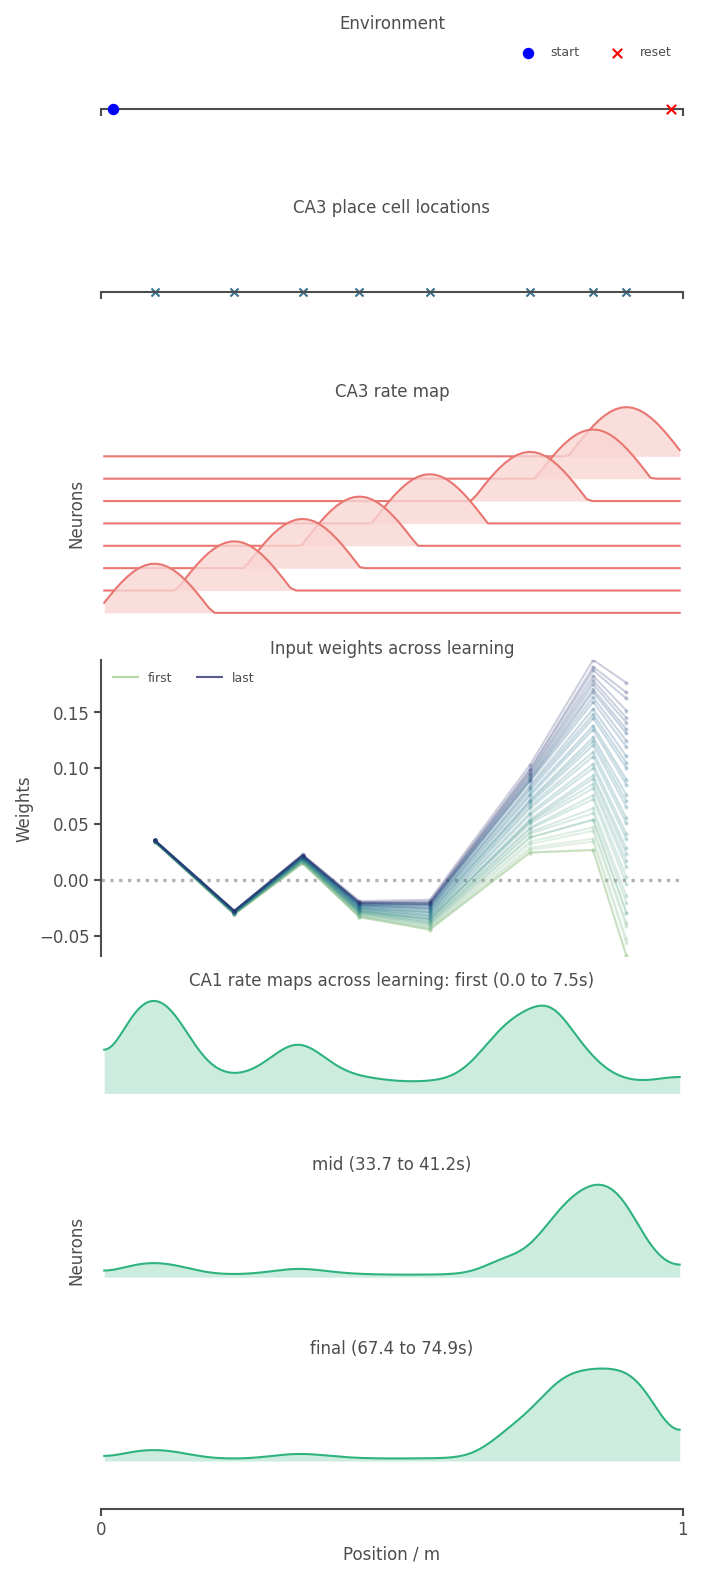

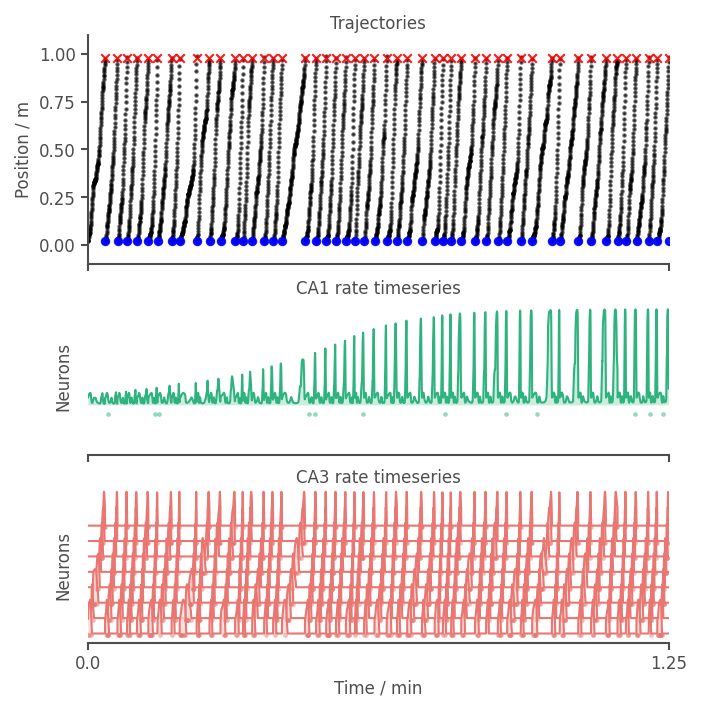

In [7]:
Env, Ag, CA1, CA3_PCs = learn(
    run_manager.ENV_PARAMS, 
    run_manager.AGENT_PARAMS, 
    run_manager.CA3_PC_PARAMS, 
    CA1_params_one, 
    num_rwd=NUM_RWD, 
    max_steps=MAX_STEPS
)

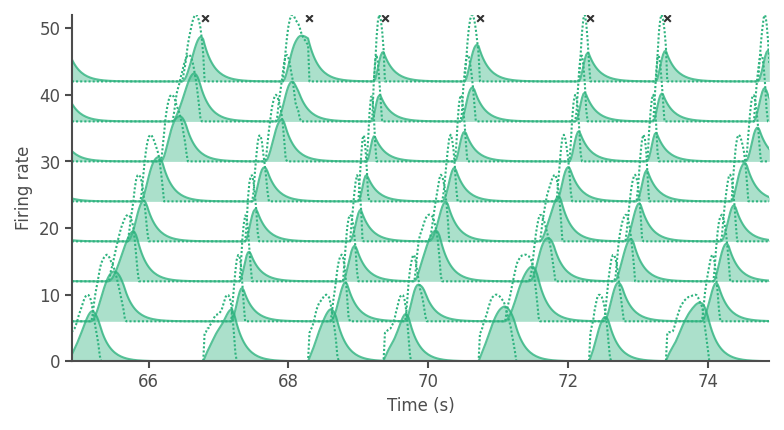

In [8]:
CA1.plot_btsp_filtered("CA3_PCs", t_start=-10);

## Multiple CA1 neurons

In [9]:
NUM_CA1 = 4

CA1_ZERO = False
CA1_SCALE = 0.1

NUM_RWD = 50
MAX_STEPS = 5000

CA1_params_mult = copy.deepcopy(run_manager.CA1_PARAMS)
CA1_params_mult["n"] = NUM_CA1
CA1_params_mult["init_weights_zero"] = CA1_ZERO
CA1_params_mult["w_init_scale"] = CA1_SCALE
CA1_params_one["btsp_tau"] = run_manager.AGENT_PARAMS["dt"] * 8

Agent dt        : 0.02
# CA3 PCs       : 8
# CA1s          : 4
CA1 init at 0   : False
CA1 init scale  : 0.1
CA1 BTSP tau    : 0.16
# rewards       : 50
Max # steps     : 5000



 75%|███████████████████████████▌         | 3727/5000 [00:00<00:00, 3987.17it/s]


Trajectory lengths (51) to date: 1.46 +/- 0.43 sec each
Trajectory lengths (51) to date: 73.10 +/- 21.27 steps each


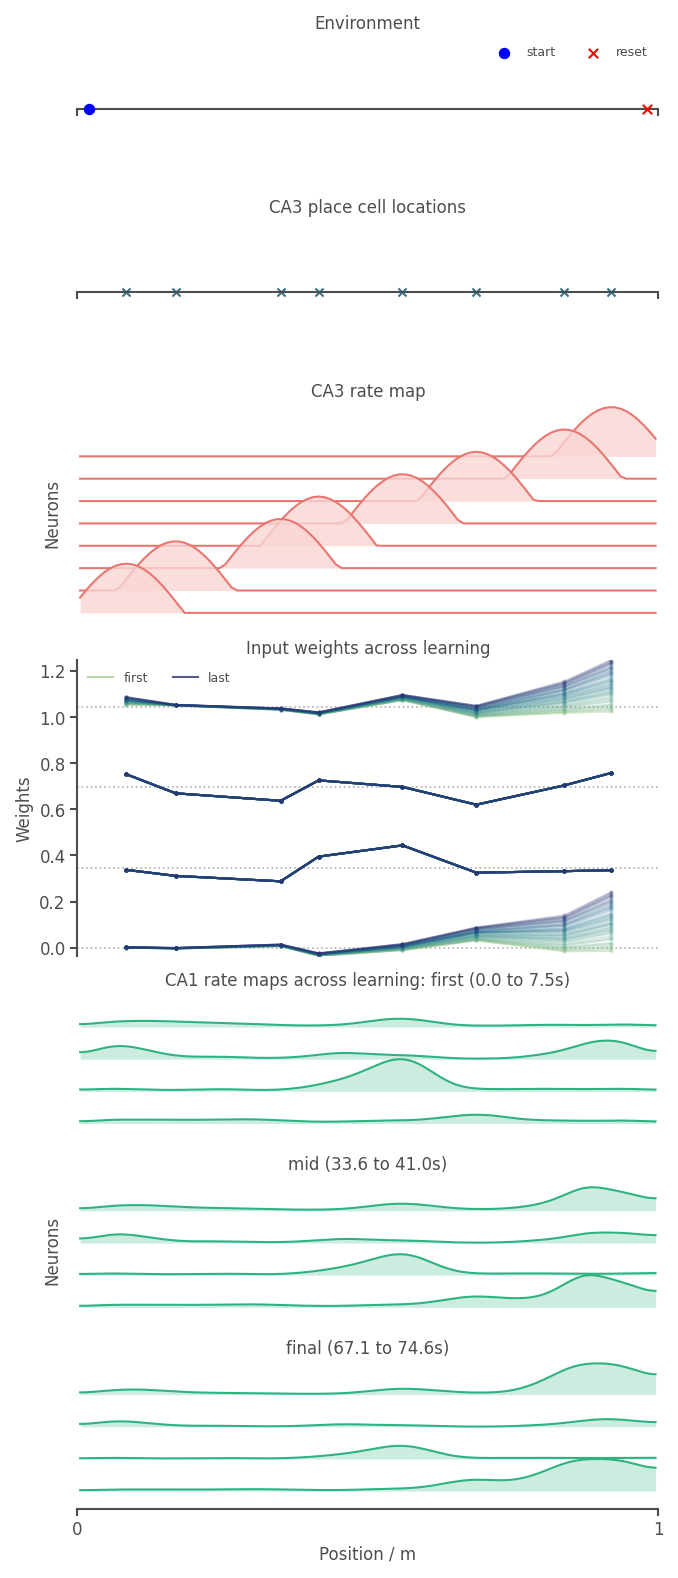

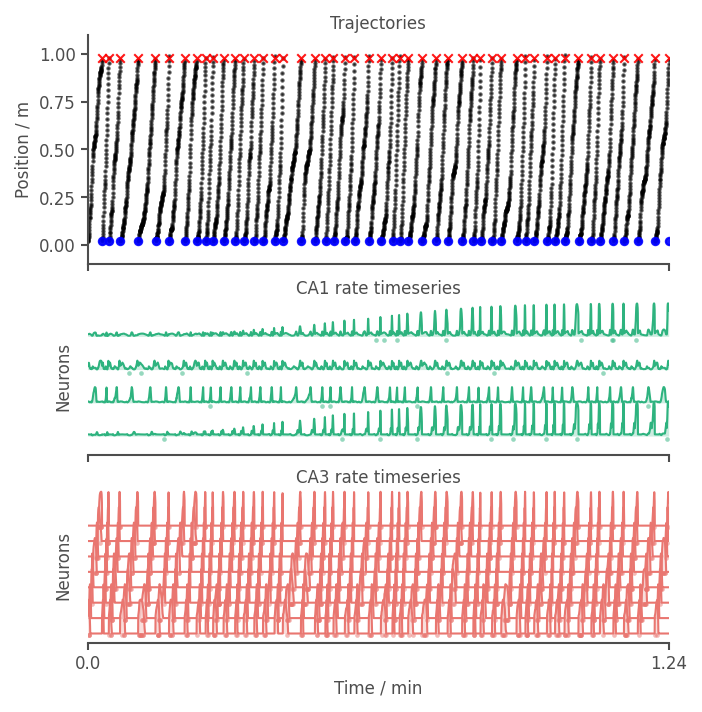

In [10]:
Env, Ag, CA1, CA3_PCs = learn(
    run_manager.ENV_PARAMS, 
    run_manager.AGENT_PARAMS, 
    run_manager.CA3_PC_PARAMS, 
    CA1_params_mult,
    num_rwd=NUM_RWD, 
    max_steps=MAX_STEPS
)

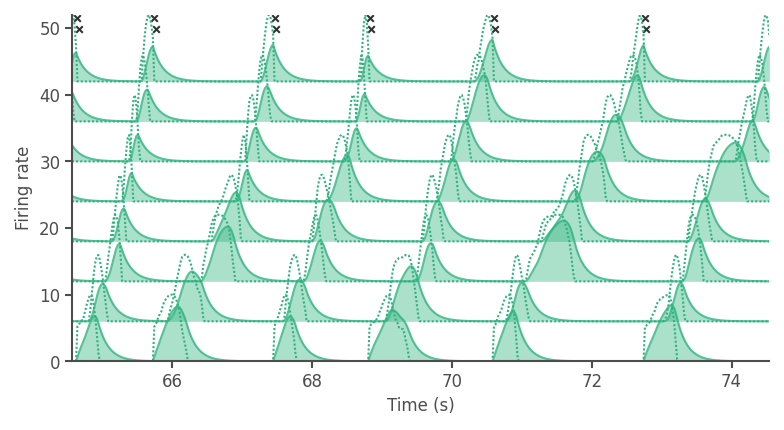

In [11]:
CA1.plot_btsp_filtered("CA3_PCs", t_start=-10);

In [12]:
# Upgrade to a 2D environment

# Add more signals (e.g., Novelty)

# Expand the network to have an EC layer (i.e., encode more environment features)

# Expand the network to have a DG-like layer (i.e., memory)

# Closing the loop: predictiveness shaping reward/novelty signal